In [1]:
#OPSO & general imports 
from opensoundscape import Audio, Spectrogram
from opensoundscape.annotations import BoxedAnnotations

# General-purpose packages
import numpy as np
import pandas as pd
from glob import glob
from pathlib import Path

from matplotlib import pyplot as plt
plt.rcParams['figure.figsize']=[15,5] #for big visuals
%config InlineBackend.figure_format = 'retina'

Load multiple Raven annotation tables

In [4]:
# Set the current directory to where the dataset is downloaded
dataset_path = Path("/home/brg226/projects/vira_beg/training_data/annotated_positive_audio/audio_viratrain/")

In [5]:
# Make a list of all of the selection table files
selections = glob(f"{dataset_path}/*.txt")
selections

['/home/brg226/projects/vira_beg/training_data/annotated_positive_audio/audio_viratrain/471280381.Table.1.selections.txt',
 '/home/brg226/projects/vira_beg/training_data/annotated_positive_audio/audio_viratrain/357857961.Table.1.selections.txt',
 '/home/brg226/projects/vira_beg/training_data/annotated_positive_audio/audio_viratrain/104728661.Table.1.selections.txt',
 '/home/brg226/projects/vira_beg/training_data/annotated_positive_audio/audio_viratrain/242259551.Table.1.selections.txt',
 '/home/brg226/projects/vira_beg/training_data/annotated_positive_audio/audio_viratrain/463875361.Table.1.selections.txt',
 '/home/brg226/projects/vira_beg/training_data/annotated_positive_audio/audio_viratrain/463875351.Table.1.selections.txt',
 '/home/brg226/projects/vira_beg/training_data/annotated_positive_audio/audio_viratrain/169224441.Table.1.selections.txt',
 '/home/brg226/projects/vira_beg/training_data/annotated_positive_audio/audio_viratrain/502891011.Table.1.selections.txt',
 '/home/brg226/p

In [6]:
# create a list of audio files, one corresponding to each Raven file
# (Audio files have the same names as selection files with a different extension)
audio_files = [
    f.replace("Annotation_Files", "Recordings").replace(
        ".Table.1.selections.txt", ".wav"
    )
    for f in selections
]

In [7]:
# create a list of audio files, one corresponding to each Raven file
# (Audio files have the same names as selection files with a different extension)
audio_files = [
    f.replace("Annotation_Files", "Recordings").replace(
        ".Table.1.selections.txt", ".wav"
    )
    for f in selections
]


In [14]:
all_annotations = BoxedAnnotations.from_raven_files(
    selections, annotation_column=None, audio_files=audio_files
)
ann_df = all_annotations.df.copy()
ann_df.head()

print(ann_df.columns.tolist())

['audio_file', 'annotation_file', 'annotation', 'start_time', 'end_time', 'low_f', 'high_f', 'Channel', 'Selection', 'View']


In [16]:

all_annotations.df['annotation']="virail"
all_annotations.df.head(300)

,audio_file,annotation_file,annotation,start_time,end_time,low_f,high_f,Channel,Selection,View
0,/home/brg226/projects/vira_beg/training_data/a...,/home/brg226/projects/vira_beg/training_data/a...,virail,0.454678,0.831582,3623.6,5724.3,1,1,Spectrogram 1
1,/home/brg226/projects/vira_beg/training_data/a...,/home/brg226/projects/vira_beg/training_data/a...,virail,2.476798,2.746016,3623.6,5409.2,1,2,Spectrogram 1
2,/home/brg226/projects/vira_beg/training_data/a...,/home/brg226/projects/vira_beg/training_data/a...,virail,4.391232,4.863858,4043.8,5829.3,1,3,Spectrogram 1
3,/home/brg226/projects/vira_beg/training_data/a...,/home/brg226/projects/vira_beg/training_data/a...,virail,2.063892,2.274722,3821.2,6380.0,1,1,Spectrogram 1
4,/home/brg226/projects/vira_beg/training_data/a...,/home/brg226/projects/vira_beg/training_data/a...,virail,9.634397,9.922152,3889.4,5185.9,1,2,Spectrogram 1
...,...,...,...,...,...,...,...,...,...,...
268,/home/brg226/projects/vira_beg/training_data/a...,/home/brg226/projects/vira_beg/training_data/a...,virail,2.814338,3.248776,2943.2,3860.0,1,1,Spectrogram 1
269,/home/brg226/projects/vira_beg/training_data/a...,/home/brg226/projects/vira_beg/training_data/a...,virail,6.510570,6.873348,3377.5,4487.2,1,2,Spectrogram 1
270,/home/brg226/projects/vira_beg/training_data/a...,/home/brg226/projects/vira_beg/training_data/a...,virail,12.590922,13.007445,2991.5,4053.0,1,3,Spectrogram 1
271,/home/brg226/projects/vira_beg/training_data/a...,/home/brg226/projects/vira_beg/training_data/a...,virail,21.508953,21.858295,2822.6,3908.2,1,4,Spectrogram 1


In [17]:
positive_vira = ann_df[["audio_file", "start_time"]].copy()
positive_vira = positive_vira.rename(columns={"audio_file": "file"})

# build 1-second clips starting exactly at the annotation start
positive_vira["end_time"] = positive_vira["start_time"] + 1.0
positive_vira["virail"] = 1

# optional but good safety checks
positive_vira = positive_vira.drop_duplicates()
positive_vira = positive_vira[positive_vira["end_time"] > positive_vira["start_time"]]

# OpenSoundscape-style index
positive_vira = positive_vira.set_index(["file", "start_time", "end_time"]).sort_index()

positive_vira.head()

virail
file                                               start_time end_time        
/home/brg226/projects/vira_beg/training_data/an... 0.378303   1.378303       1
                                                   0.876813   1.876813       1
                                                   2.164027   3.164027       1
                                                   3.380698   4.380698       1
                                                   4.314080   5.314080       1

In [18]:
POS_DIR = Path("/media/auk/projects/gak76/vira_beg_outputs/training_data/positives")
POS_DIR.mkdir(parents=True, exist_ok=True)

positive_vira.to_pickle(POS_DIR / "positive_vira_1s_gk.pkl")

Mess around w/ audio visualization of training data

/home/brg226/projects/vira_beg/training_data/annotated_positive_audio/audio_viratrain/104566671.wav
0.378302527 1.378302527


/home/sml161/miniconda3/envs/perch2/lib/python3.11/site-packages/matplotlib_inline/config.py:68: DeprecationWarning: InlineBackend._figure_format_changed is deprecated in traitlets 4.1: use @observe and @unobserve instead.
  def _figure_format_changed(self, name, old, new):


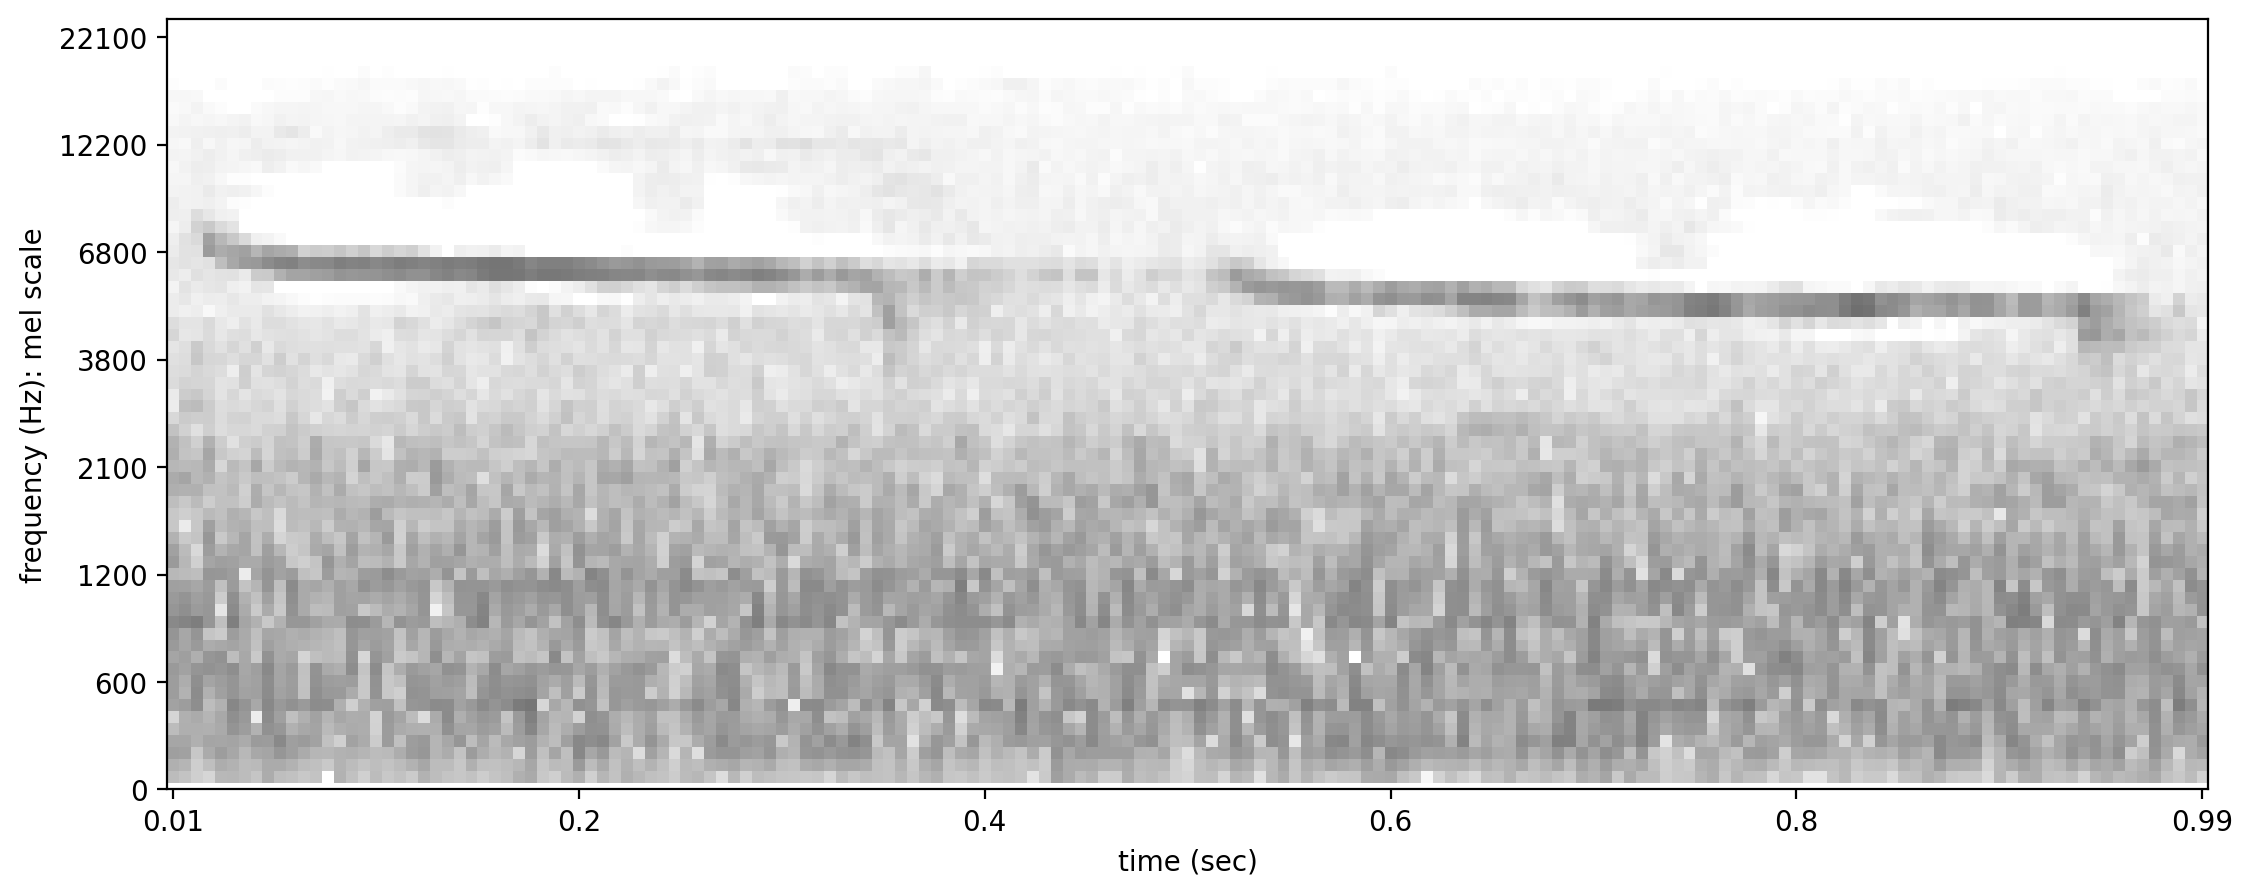

In [19]:
from opensoundscape.audio import Audio
from opensoundscape.spectrogram import MelSpectrogram
import matplotlib.pyplot as plt

# grab one positive example
example = positive_vira.reset_index().iloc[0]

file = example["file"]
start = example["start_time"]
end = example["end_time"]

print(file)
print(start, end)

# load full audio file, then trim to the positive clip
audio = Audio.from_file(file)
clip = audio.trim(start_time=start, end_time=end)

# listen to the clip
clip.show_widget()

# make a mel spectrogram
spec = MelSpectrogram.from_audio(clip)

# plot it
spec.plot()
plt.show()

Visualize confusion sp.

In [ ]:
BLJA_object = Audio.from_file('/home/brg226/projects/rloc/VIRA_beg/raven_annotations/confusion_sp/XC1036141 - Blue Jay - Cyanocitta cristata.mp3')
RWBL_object = Audio.from_file('/home/brg226/projects/rloc/VIRA_beg/raven_annotations/confusion_sp/XC1004470 - Red-winged Blackbird - Agelaius phoeniceus.mp3')
BCCH_object = Audio.from_file('/home/brg226/projects/rloc/VIRA_beg/raven_annotations/confusion_sp/XC335758 - Black-capped Chickadee - Poecile atricapillus.mp3')

In [ ]:
spectrogram_object = Spectrogram.from_audio(BLJA_object.trim(0,10))
spectrogram_object.plot()

In [ ]:
spectrogram_object = Spectrogram.from_audio(RWBL_object.trim(0,10))
spectrogram_object.plot()

In [ ]:
spectrogram_object = Spectrogram.from_audio(BCCH_object.trim(0,10))
spectrogram_object.plot()

Explore field data

In [ ]:
field_audio_object = Audio.from_file('/home/brg226/projects/rloc/datasets/rloc2024a_sync/MSD-0382/20240515_000000.WAV')
field_audio_object

In [ ]:
spectrogram_object = Spectrogram.from_audio(field_audio_object)
spectrogram_object.plot()

In [ ]:
from opensoundscape.spectrogram import MelSpectrogram
melspec = MelSpectrogram.from_audio(
    field_audio_object.trim(0, 40), window_samples=2048, n_mels=400
)
from matplotlib import pyplot as plt

melspec.plot()

Field data looks very simialr to training data, besides some weird band of mechanical noise @ 100 hZ in field data. The field data has more species than the target recordings of target and confusion species.